# Lesson 6 — Counting: permutations & combinations

*Part 1 · Lesson 6 of 20  ·  data: dice & cards (simulation)*

**←** [Lesson 5: Probability & conditional probability](05-probability.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  [Lesson 7: Random variables, expectation & variance](07-random-variables.ipynb) **→**

**Welcome.** A huge amount of probability is really just *careful counting*. If every
outcome is equally likely, then the probability of something is simply

$$P(\text{event}) = \frac{\text{number of outcomes we want}}{\text{number of outcomes possible}}.$$

So the whole game becomes: **how do you count outcomes without listing them all?** We'll meet the
three tools that do it — the **multiplication principle**, **permutations** (order matters), and
**combinations** (order doesn't) — and we'll *never just trust a formula*. Every count gets checked
two ways: by **brute-force enumeration** (literally listing the outcomes with `itertools`) and by
**simulation** (drawing at random and watching the frequencies settle). At the end we use this to
explain the mysterious "$n$ choose $k$" inside the binomial, and to crack the famously surprising
**birthday problem**.

Run each grey cell with **Shift + Enter**, then tinker.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
from scipy.special import comb, perm, factorial   # the counting functions, ready-made
sl.use_course_style()

rng = np.random.default_rng(13)   # fixed seed -> reproducible; change it to reshuffle the luck
print("Ready. No dataset to load today - we'll generate every outcome ourselves.")

Ready. No dataset to load today - we'll generate every outcome ourselves.


## 1) The fundamental counting principle — just multiply

The single most useful idea in counting:

> If one choice can be made in $a$ ways, and *then* a second choice in $b$ ways, and *then* a
> third in $c$ ways, the number of combined outcomes is $a \times b \times c$.

- **The math:** multiply the number of options at each independent step.
- **The meaning:** each option at step 1 "fans out" into all the options at step 2, and so on — a tree
  that branches $a$, then $b$, then $c$ times.
- **The interpretation:** counting compound outcomes almost never needs a clever trick; it needs you to
  break the situation into ordered steps and multiply.

Roll **two dice**: the first can land $6$ ways, the second $6$ ways, so $6 \times 6 = 36$ outcomes.
Let's not take that on faith — let's *list every single one* and count them.

In [2]:
# itertools.product gives every (die1, die2) pair - the literal sample space.
all_pairs = list(itertools.product(range(1, 7), range(1, 7)))
print(f"Counting principle says: 6 x 6 = {6 * 6} outcomes")
print(f"Brute force found:       {len(all_pairs)} outcomes")
print("\nThe first eight pairs:", all_pairs[:8])
print("The last  eight pairs:", all_pairs[-8:])

Counting principle says: 6 x 6 = 36 outcomes
Brute force found:       36 outcomes

The first eight pairs: [(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (2, 1), (2, 2)]
The last  eight pairs: [(5, 5), (5, 6), (6, 1), (6, 2), (6, 3), (6, 4), (6, 5), (6, 6)]


## 2) Factorials — counting *arrangements* of everything

A special case: in how many orders can you arrange $n$ *distinct* things in a row? The first slot has
$n$ choices, the next $n-1$ (one is used up), then $n-2$, ... down to $1$. Multiply them all:

$$n! = n \times (n-1) \times (n-2) \times \cdots \times 2 \times 1, \qquad 0! = 1.$$

This is the **factorial** ("$n$ factorial"). It grows *ferociously* fast — that's why listing all
outcomes stops being possible very quickly, and why we need formulas. Three letters A, B, C have
$3! = 6$ orderings; let's list them to be sure, then watch $n!$ explode.

In [3]:
letters = ['A', 'B', 'C']
orderings = list(itertools.permutations(letters))   # every full ordering
print(f"3! = {factorial(3, exact=True)}  arrangements of {letters}:")
for o in orderings:
    print("   ", ''.join(o))

print("\nHow fast does n! grow?")
for n in [1, 3, 5, 10, 13, 20]:
    print(f"  {n:>2}! = {factorial(n, exact=True):,}")

3! = 6  arrangements of ['A', 'B', 'C']:
    ABC
    ACB
    BAC
    BCA
    CAB
    CBA

How fast does n! grow?
   1! = 1
   3! = 6
   5! = 120
  10! = 3,628,800
  13! = 6,227,020,800
  20! = 2,432,902,008,176,640,000


## 3) Permutations — order matters: $_nP_r$

Often we don't arrange *everything*, just pick $r$ items out of $n$ and **care about the order**
(think: gold / silver / bronze medals — 1st vs 2nd is a different result). The number of such ordered
picks is the **permutation** count:

$$_nP_r = \frac{n!}{(n-r)!} = \underbrace{n \times (n-1) \times \cdots \times (n-r+1)}_{r \text{ factors}}.$$

- **The math:** start the factorial product but stop after $r$ factors.
- **The meaning:** $r$ ordered slots, each filled from the dwindling pool — $n$ ways for the first, $n-1$
  for the second, and so on.
- **The interpretation:** use this when rearranging the *same* items into a different order counts as a
  *different* outcome.

Take $n = 4$ runners $\{A, B, C, D\}$ and hand out gold/silver ($r = 2$). The formula says
$_4P_2 = \frac{4!}{2!} = 12$. Let's enumerate every ordered podium and confirm.

In [4]:
runners = ['A', 'B', 'C', 'D']
r = 2
ordered_picks = list(itertools.permutations(runners, r))   # ORDER matters: ('A','B') != ('B','A')

print(f"nPr formula  : 4P2 = {perm(4, 2, exact=True)}")
print(f"Brute force  : {len(ordered_picks)} ordered podiums\n")
print("Every (gold, silver) outcome:")
for g, s in ordered_picks:
    print(f"   gold={g}, silver={s}")
print("\nNotice ('A','B') and ('B','A') are BOTH here - order is a different result.")

nPr formula  : 4P2 = 12
Brute force  : 12 ordered podiums

Every (gold, silver) outcome:
   gold=A, silver=B
   gold=A, silver=C
   gold=A, silver=D
   gold=B, silver=A
   gold=B, silver=C
   gold=B, silver=D
   gold=C, silver=A
   gold=C, silver=B
   gold=C, silver=D
   gold=D, silver=A
   gold=D, silver=B
   gold=D, silver=C

Notice ('A','B') and ('B','A') are BOTH here - order is a different result.


## 4) Combinations — order does *not* matter: $_nC_r$ = "$n$ choose $k$"

Now suppose order is irrelevant — you just pick a *group* (a committee, a hand of cards, a set of
lottery numbers). Picking $\{A, B\}$ is the same group as $\{B, A\}$. Each unordered group of size $r$
was counted $r!$ times among the permutations (once for every internal ordering), so we divide it out:

$$_nC_r = \binom{n}{r} = \frac{_nP_r}{r!} = \frac{n!}{r!\,(n-r)!}.$$

This is the **combination** count, read "$n$ choose $r$" and written $\binom{n}{r}$.

- **The math:** permutations, then divide by $r!$ to erase the orderings within each group.
- **The meaning:** the number of distinct *subsets* of size $r$ — order ignored.
- **The interpretation:** use this when the items are a set, not a sequence; rearranging them is the
  *same* outcome.

Same 4 runners, choose a group of 2: $\binom{4}{2} = \frac{12}{2!} = 6$. Watch the count drop from 12
(ordered) to 6 (unordered) because each pair is no longer double-counted.

In [5]:
groups = list(itertools.combinations(runners, r))   # ORDER ignored: ('A','B') only, never ('B','A')

print(f"nCr formula : 4C2 = {comb(4, 2, exact=True)}")
print(f"Brute force : {len(groups)} unordered groups\n")
print("Every group of 2 (order ignored):")
for grp in groups:
    print("    {" + ", ".join(grp) + "}")   # a set/group; printed in a stable order
print(f"\nPermutations (12) / r! (2! = 2) = {12 // 2} = combinations. The /r! is the whole difference.")

nCr formula : 4C2 = 6
Brute force : 6 unordered groups

Every group of 2 (order ignored):
    {A, B}
    {A, C}
    {A, D}
    {B, C}
    {B, D}
    {C, D}

Permutations (12) / r! (2! = 2) = 6 = combinations. The /r! is the whole difference.


### Side by side: the same $n$, every $r$

It helps to see permutations and combinations together. For each group size $r$, permutations are
always $r!$ times larger than combinations — exactly the orderings we divided away.

In [6]:
n = 5
rows = []
for k in range(n + 1):
    rows.append({
        'r': k,
        'nPr (ordered)': perm(n, k, exact=True),
        'nCr (unordered)': comb(n, k, exact=True),
        'ratio = r!': factorial(k, exact=True),
    })
print(f"n = {n}\n")
print(pd.DataFrame(rows).to_string(index=False))
print("\nnCr is symmetric: choosing r to KEEP is the same as choosing (n-r) to LEAVE OUT.")

n = 5

 r  nPr (ordered)  nCr (unordered)  ratio = r!
 0              1                1           1
 1              5                5           1
 2             20               10           2
 3             60               10           6
 4            120                5          24
 5            120                1         120

nCr is symmetric: choosing r to KEEP is the same as choosing (n-r) to LEAVE OUT.


## 5) From counting to probability — equally-likely outcomes

When every outcome is equally likely, probability is just a *ratio of counts*:

$$P(\text{event}) = \frac{\text{favorable outcomes}}{\text{total outcomes}}.$$

**Worked example (dice).** Roll two fair dice. What's $P(\text{sum} = 7)$? We already know the total is
$6 \times 6 = 36$ equally-likely pairs. The favorable ones are the pairs that add to 7. Let's *count*
them by enumeration, get the exact probability, then **confirm by simulation** — rolling thousands of
times and watching the observed frequency drift toward the counted answer.

In [7]:
# Count the favorable outcomes exactly.
favorable = [pair for pair in all_pairs if sum(pair) == 7]
p_exact = len(favorable) / len(all_pairs)
print("Pairs that sum to 7:", favorable)
print(f"Counted probability = {len(favorable)}/{len(all_pairs)} = {p_exact:.4f}  (= 1/6)")

Pairs that sum to 7: [(1, 6), (2, 5), (3, 4), (4, 3), (5, 2), (6, 1)]
Counted probability = 6/36 = 0.1667  (= 1/6)


Simulated P(sum=7) over 60,000 rolls = 0.1664
Counted (exact) value                 = 0.1667


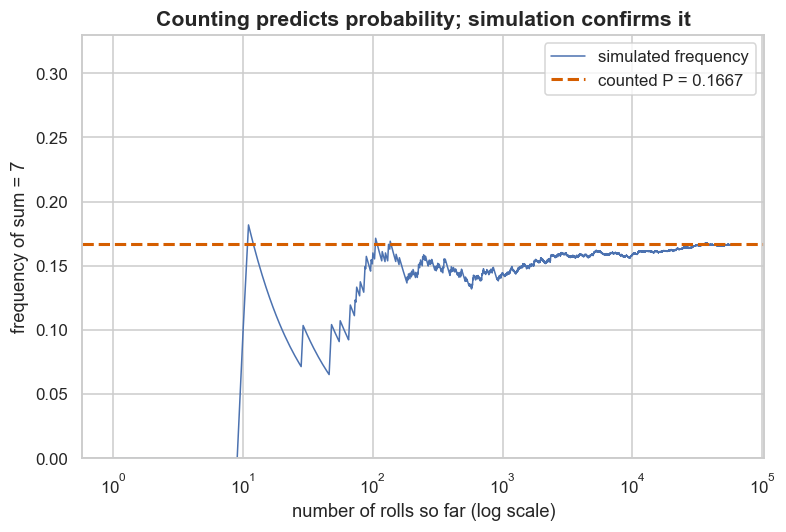

In [8]:
# Now CONFIRM by Monte-Carlo simulation: roll two dice many times and tally.
n_rolls = 60_000
d1 = rng.integers(1, 7, size=n_rolls)
d2 = rng.integers(1, 7, size=n_rolls)
sums = d1 + d2
p_sim = np.mean(sums == 7)
print(f"Simulated P(sum=7) over {n_rolls:,} rolls = {p_sim:.4f}")
print(f"Counted (exact) value                 = {p_exact:.4f}")

# Watch the running frequency settle onto the exact line.
hit = (sums == 7).astype(float)
running = np.cumsum(hit) / np.arange(1, n_rolls + 1)

fig, ax = plt.subplots()
ax.plot(np.arange(1, n_rolls + 1), running, color='#4c72b0', lw=1.0, label='simulated frequency')
ax.axhline(p_exact, color='#D55E00', lw=2, ls='--', label=f'counted P = {p_exact:.4f}')
ax.set_xscale('log')
ax.set_xlabel('number of rolls so far (log scale)'); ax.set_ylabel('frequency of sum = 7')
ax.set_title('Counting predicts probability; simulation confirms it')
ax.set_ylim(0, 0.33); ax.legend(); plt.show()

**A combination-flavored probability.** Deal a 5-card poker hand from a standard 52-card deck. How many
possible hands are there? Order of the cards in your hand doesn't matter, so it's a *combination*:
$\binom{52}{5}$. The chance of a specific kind of hand is (number of those hands) $\div \binom{52}{5}$.

Take a **flush** drawn from a single suit: pick one of the 4 suits, then choose 5 of its 13 cards —
$4 \times \binom{13}{5}$ hands. (This counts straight flushes too; the textbook "flush" excludes them,
but it's a clean counting demo.)

In [9]:
total_hands = comb(52, 5, exact=True)
flush_hands = 4 * comb(13, 5, exact=True)        # 4 suits, choose 5 of 13 cards in that suit
p_flush = flush_hands / total_hands
print(f"Total 5-card hands  : C(52,5) = {total_hands:,}")
print(f"Flush hands         : 4 x C(13,5) = {flush_hands:,}")
print(f"P(flush)            = {p_flush:.6f}   (about 1 in {1 / p_flush:.0f} hands)")

Total 5-card hands  : C(52,5) = 2,598,960
Flush hands         : 4 x C(13,5) = 5,148
P(flush)            = 0.001981   (about 1 in 505 hands)


## 6) The bridge to the binomial — *why* there's an "$n$ choose $k$"

Here's the payoff that makes this lesson the foundation for the next one. Suppose you run $n$
independent yes/no trials (coin flips, free throws, whether each baby is low birth-weight). You want
the probability of getting **exactly $k$ successes**.

A single sequence with $k$ successes and $n-k$ failures — say `SSFSF` — has probability
$p^k (1-p)^{n-k}$, where $p = P(\text{success})$. But $k$ successes can be **arranged** among the $n$
slots in many different orders, and *every one of those arrangements* has that same probability. How
many arrangements? That's exactly "choose which $k$ of the $n$ slots are successes" —

$$\binom{n}{k} \text{ arrangements.}$$

Add them up and you get the **binomial formula**:

$$P(X = k) = \binom{n}{k}\, p^{k} (1-p)^{n-k}.$$

The $\binom{n}{k}$ out front is **not magic** — it is the *count* of orderings we learned above. Let's
literally list the arrangements for a small case so you can see the binomial coefficient appear.

In [10]:
n, k = 5, 2     # 5 trials, want exactly 2 successes  (<- tinker with these)

# Every way to place exactly k S's among n slots = choose which positions are successes.
arrangements = []
for positions in itertools.combinations(range(n), k):   # which slots are the successes
    seq = ['F'] * n
    for pos in positions:
        seq[pos] = 'S'
    arrangements.append(''.join(seq))

print(f"All sequences of {n} trials with exactly {k} successes:")
for seq in arrangements:
    print("   ", seq)
print(f"\nBrute-force count : {len(arrangements)} arrangements")
print(f"C(n,k) = C({n},{k}) : {comb(n, k, exact=True)}   <- the binomial coefficient, matched exactly")

All sequences of 5 trials with exactly 2 successes:
    SSFFF
    SFSFF
    SFFSF
    SFFFS
    FSSFF
    FSFSF
    FSFFS
    FFSSF
    FFSFS
    FFFSS

Brute-force count : 10 arrangements
C(n,k) = C(5,2) : 10   <- the binomial coefficient, matched exactly


So the "$\binom{n}{k}$" factor in the binomial PMF is simply *how many orderings of $k$ successes in $n$
trials there are*. The **next lesson** builds the full binomial (and Poisson) distributions on top of
exactly this idea — now you know where that coefficient comes from.

## 7) The birthday problem — counting in disguise

A famous, genuinely surprising result: in a room of just **23 people**, it's slightly *more likely than
not* that two of them share a birthday. Most people guess you'd need 100+. Counting settles it.

It's far easier to count the **complement** — the chance that *everyone's birthday is different* — and
subtract from 1. Assume 365 equally-likely birthdays and a group of $k$ people. The number of ways for
all $k$ birthdays to be **distinct** is an ordered pick of $k$ days from 365, i.e. $_{365}P_k$. The
total number of birthday assignments is $365^k$. So

$$P(\text{all different}) = \frac{_{365}P_k}{365^{k}}, \qquad
P(\text{at least one shared}) = 1 - \frac{_{365}P_k}{365^{k}}.$$

In [11]:
def p_shared_birthday(k):
    'Exact P(at least two of k people share a birthday), via counting.'
    if k > 365:
        return 1.0
    # P(all different) = (365 P k) / 365^k  -- build it as a product to stay numerically safe.
    p_all_different = 1.0
    for i in range(k):
        p_all_different *= (365 - i) / 365
    return 1 - p_all_different

for k in [5, 10, 23, 30, 50, 70]:
    print(f"group of {k:>2}: P(a shared birthday) = {p_shared_birthday(k):.3f}")
print(f"\nAt 23 people it first crosses 50%: P = {p_shared_birthday(23):.3f}")

group of  5: P(a shared birthday) = 0.027
group of 10: P(a shared birthday) = 0.117
group of 23: P(a shared birthday) = 0.507
group of 30: P(a shared birthday) = 0.706
group of 50: P(a shared birthday) = 0.970
group of 70: P(a shared birthday) = 0.999

At 23 people it first crosses 50%: P = 0.507


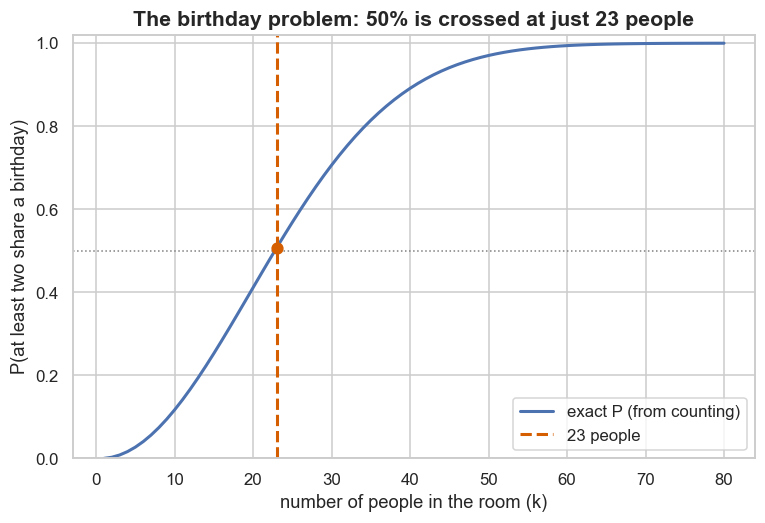

In [12]:
# Plot the exact curve and mark the 23-person, 50% crossing point.
ks = np.arange(1, 81)
p_exact_curve = np.array([p_shared_birthday(int(k)) for k in ks])

fig, ax = plt.subplots()
ax.plot(ks, p_exact_curve, color='#4c72b0', lw=2, label='exact P (from counting)')
ax.axhline(0.5, color='grey', ls=':', lw=1)
ax.axvline(23, color='#D55E00', ls='--', lw=2, label='23 people')
ax.plot(23, p_shared_birthday(23), 'o', color='#D55E00', ms=7)
ax.set_xlabel('number of people in the room (k)')
ax.set_ylabel('P(at least two share a birthday)')
ax.set_title('The birthday problem: 50% is crossed at just 23 people')
ax.set_ylim(0, 1.02); ax.legend(); plt.show()

### Confirm it by simulation

The counting answer feels too good to be true, so let's *make rooms of people* at random and check how
often a birthday actually repeats. We'll simulate many rooms of 23 and compare the simulated rate to the
exact $\approx 0.507$.

In [13]:
def simulate_shared(k, n_rooms=20_000):
    'Fraction of simulated rooms of k people that contain a repeated birthday.'
    shared = 0
    for _ in range(n_rooms):
        birthdays = rng.integers(0, 365, size=k)       # k random birthdays
        if len(np.unique(birthdays)) < k:              # a repeat exists
            shared += 1
    return shared / n_rooms

k = 23
sim = simulate_shared(k)
print(f"Simulated P(shared) for {k} people = {sim:.3f}")
print(f"Exact (counted) value             = {p_shared_birthday(k):.3f}")
print("Close - and they'd match even better with more rooms or a different seed.")

Simulated P(shared) for 23 people = 0.508
Exact (counted) value             = 0.507
Close - and they'd match even better with more rooms or a different seed.


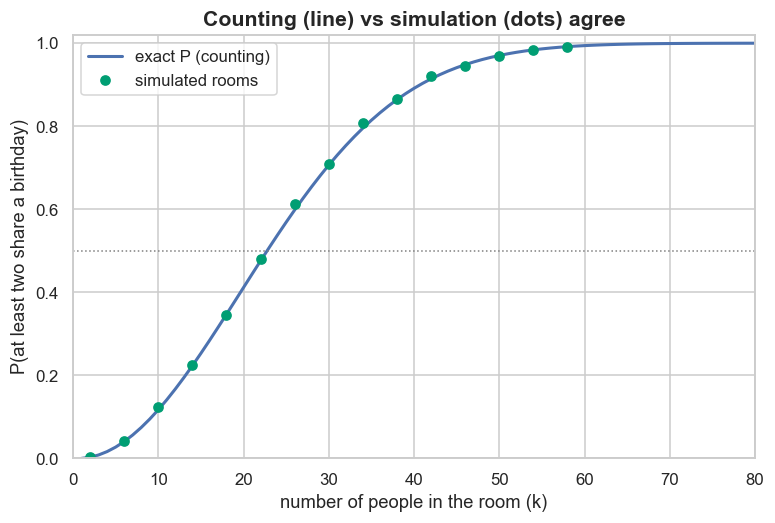

In [14]:
# Overlay simulation on the exact curve across many group sizes.
ks_sim = np.arange(2, 61, 4)
sim_curve = np.array([simulate_shared(int(k), n_rooms=4000) for k in ks_sim])

fig, ax = plt.subplots()
ax.plot(ks, p_exact_curve, color='#4c72b0', lw=2, label='exact P (counting)')
ax.plot(ks_sim, sim_curve, 'o', color='#009E73', ms=6, label='simulated rooms')
ax.axhline(0.5, color='grey', ls=':', lw=1)
ax.set_xlabel('number of people in the room (k)')
ax.set_ylabel('P(at least two share a birthday)')
ax.set_title('Counting (line) vs simulation (dots) agree')
ax.set_xlim(0, 80); ax.set_ylim(0, 1.02); ax.legend(); plt.show()

## Now you try

Predict first, then change one thing and re-run:

1. **Change $r$.** In the permutations/combinations cells (Sections 3-4), set `r = 3` and re-run. How
   many ordered podiums vs. unordered groups now? Check that $_4P_3$ is still exactly $3! = 6$ times
   $\binom{4}{3}$.
2. **Change the binomial case.** In Section 6, set `n, k = 6, 3`. List the arrangements — do you count
   $\binom{6}{3} = 20$ of them? Try `k = 0` and `k = 6`: why is each of those exactly **one** arrangement?
3. **Change the birthday group size.** Call `p_shared_birthday(40)` and `simulate_shared(40)` in a new
   cell. How surprised are you that 40 people are almost *guaranteed* a match?
4. **Reshuffle the luck.** Change the seed `np.random.default_rng(13)` in Setup to any other number and
   re-run the simulations. The exact (counted) values don't budge, but the simulated estimates wiggle a
   little each time — that wiggle *is* sampling variability.

## What you learned

- **Equally-likely outcomes** turn probability into pure counting: $P = \dfrac{\text{favorable}}{\text{total}}$.
- The **fundamental counting principle** says multiply the choices at each independent step; **factorials**
  $n!$ count full arrangements and grow explosively.
- **Permutations** $_nP_r = \dfrac{n!}{(n-r)!}$ count ordered picks (order matters); **combinations**
  $\binom{n}{r} = \dfrac{n!}{r!(n-r)!}$ count unordered groups (order doesn't) — they differ exactly by the
  $r!$ internal orderings.
- We never trusted a formula blindly: **`itertools` enumeration** and **Monte-Carlo simulation** both
  confirmed every count.
- The "$n$ choose $k$" in the **binomial** is just the number of ways to arrange $k$ successes among $n$
  trials — the bridge to the next lesson.
- The **birthday problem** shows counting beating intuition: only **23 people** are needed for a better-
  than-even chance of a shared birthday, confirmed by simulating thousands of rooms.

**Next:** the **binomial & Poisson** lesson puts that $\binom{n}{k}$ to work, building full distributions
for counts of successes and rare events.

---

**← Previous:** [Lesson 5: Probability & conditional probability](05-probability.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Next →:** [Lesson 7: Random variables, expectation & variance](07-random-variables.ipynb)